# **Project Name**    - Tourism Experience Analytics: Classification, Prediction, and Recommendation System

# **Problem Statement**

Tourism agencies and travel platforms aim to enhance user experiences by leveraging data to provide personalized recommendations, predict user satisfaction, and classify potential user behavior. This project involves analyzing user preferences, travel patterns, and attraction features to achieve three primary objectives: regression, classification, and recommendation.

# **GitHub Link -**

**https://github.com/21f1003070/Innovexis-AIML-Internship/tree/Tourism-Experience-Analytics**

# **Import Libraries**

In [1]:
# Importing libraries for data manipulation and analysis
import pandas as pd
import numpy as np

# Importing libraries for visualization
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Importing Scikit-learn for model building and evaluation
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import MinMaxScaler

# Importing for Statistical analysis
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Set plot style
sns.set_style('whitegrid')


# **Dataset Loading**

In [3]:
#Loading the transaction dataset

from google.colab import files
uploaded=files.upload()
transaction=pd.read_excel ('Transaction.xlsx')

Saving Transaction.xlsx to Transaction.xlsx


In [4]:
#Loading the users dataset

from google.colab import files
uploaded=files.upload()
users=pd.read_excel ('User.xlsx')

Saving User.xlsx to User.xlsx


In [5]:
#Loading the city dataset

from google.colab import files
uploaded=files.upload()
city=pd.read_excel ('City.xlsx')

Saving City.xlsx to City.xlsx


In [6]:
#Loading the country dataset

from google.colab import files
uploaded=files.upload()
country=pd.read_excel ('Country.xlsx')

Saving Country.xlsx to Country.xlsx


In [7]:
#Loading the region dataset

from google.colab import files
uploaded=files.upload()
region=pd.read_excel ('Region.xlsx')

Saving Region.xlsx to Region.xlsx


In [8]:
#Loading the continent dataset

from google.colab import files
uploaded=files.upload()
continent=pd.read_excel ('Continent.xlsx')

Saving Continent.xlsx to Continent.xlsx


In [9]:
#Loading the types dataset

from google.colab import files
uploaded=files.upload()
types=pd.read_excel ('Type.xlsx')

Saving Type.xlsx to Type.xlsx


In [10]:
#Loading the mode dataset

from google.colab import files
uploaded=files.upload()
mode=pd.read_excel ('Mode.xlsx')

Saving Mode.xlsx to Mode.xlsx


In [11]:
#Loading the item dataset

from google.colab import files
uploaded=files.upload()
item=pd.read_excel ('Item.xlsx')

Saving Item.xlsx to Item.xlsx


# **Dataset First View**

In [12]:
#Viweing first 5 rows of the transaction dataset

transaction.head()


,TransactionId,UserId,VisitYear,VisitMonth,VisitMode,AttractionId,Rating
0,3,70456,2022,10,2,640,5
1,8,7567,2022,10,4,640,5
2,9,79069,2022,10,3,640,5
3,10,31019,2022,10,3,640,3
4,15,43611,2022,10,2,640,3


In [13]:
#Viweing first 5 rows of the users dataset

users.head()


,UserId,ContinentId,RegionId,CountryId,CityId
0,14,5,20,155,220.0
1,16,3,14,101,3098.0
2,20,4,15,109,4303.0
3,23,1,4,22,154.0
4,25,3,14,101,3098.0


In [14]:
#Viweing first 5 rows of the city dataset

city.head()

,CityId,CityName,CountryId
0,0,-,0
1,1,Douala,1
2,2,South Region,1
3,3,N'Djamena,2
4,4,Kigali,3


In [15]:
#Viweing first 5 rows of the country dataset

country.head()

,CountryId,Country,RegionId
0,0,-,0
1,1,Cameroon,1
2,2,Chad,1
3,3,Rwanda,1
4,4,Ethiopia,2


In [16]:
#Viweing first 5 rows of the region dataset

region.head()

,Region,RegionId,ContinentId
0,-,0,0
1,Central Africa,1,1
2,East Africa,2,1
3,North Africa,3,1
4,Southern Africa,4,1


In [17]:
#Viweing first 5 rows of the continent dataset

continent.head()

,ContinentId,Continent
0,0,-
1,1,Africa
2,2,America
3,3,Asia
4,4,Australia & Oceania


In [19]:
#Viweing first 5 rows of the types dataset

types.head()

,AttractionTypeId,AttractionType
0,2,Ancient Ruins
1,10,Ballets
2,13,Beaches
3,19,Caverns & Caves
4,34,Flea & Street Markets


In [20]:
#Viweing first 5 rows of the mode dataset

mode.head()

,VisitModeId,VisitMode
0,0,-
1,1,Business
2,2,Couples
3,3,Family
4,4,Friends


In [21]:
#Viweing first 5 rows of item dataset

item.head()

,AttractionId,AttractionCityId,AttractionTypeId,Attraction,AttractionAddress
0,369,1,13,Kuta Beach - Bali,Kuta
1,481,1,13,Nusa Dua Beach,"Semenanjung Nusa Dua, Nusa Dua 80517 Indonesia"
2,640,1,63,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia"
3,650,1,13,Sanur Beach,Sanur
4,673,1,13,Seminyak Beach,Seminyak


# **Data Cleaning**

# Handle missing values in the transaction, user, and city datasets.

In [22]:
#Checking the existence of missing values in the transaction dataset

transaction.isnull().sum()

,0
TransactionId,0
UserId,0
VisitYear,0
VisitMonth,0
VisitMode,0
AttractionId,0
Rating,0


In [23]:
#Checking the existence of missing values in the users dataset

users.isnull().sum()

,0
UserId,0
ContinentId,0
RegionId,0
CountryId,0
CityId,4


In [24]:
#Checking the existence of missing values in the city dataset

city.isnull().sum()

,0
CityId,0
CityName,1
CountryId,0


# For rest of the datasets too, just to confirm whether they contain missing values

In [25]:
continent.isnull().sum()

,0
ContinentId,0
Continent,0


In [28]:
country.isnull().sum()

,0
CountryId,0
Country,0
RegionId,0


In [29]:
region.isnull().sum()

,0
Region,0
RegionId,0
ContinentId,0


In [30]:
types.isnull().sum()

,0
AttractionTypeId,0
AttractionType,0


In [31]:
mode.isnull().sum()

,0
VisitModeId,0
VisitMode,0


In [32]:
item.isnull().sum()

,0
AttractionId,0
AttractionCityId,0
AttractionTypeId,0
Attraction,0
AttractionAddress,0


In [33]:
# 1. Handling missing CityId in users dataset
# Since CityId is a key to be used for joining tables, we can fill missing IDs with a placeholder (-1)
users['CityId'] = users['CityId'].fillna(-1).astype(int)

# Handling missing CityName in city dataset
# Since it is a string variable, we can fill it with 'Unknown'
city['CityName'] = city['CityName'].fillna('Unknown')

# Adding a placeholder row in the city dataset to handle the -1 CityId safely during merges
placeholder_row = pd.DataFrame([{'CityId': -1, 'CityName': 'Unknown', 'CountryId': -1}])
city = pd.concat([city, placeholder_row], ignore_index=True)

# Verify that all nulls are resolved
print("Missing values in the users dataset after fix:\n", users.isnull().sum())
print("\nMissing values in the city dataset after fix:\n", city.isnull().sum())


Missing values in the users dataset after fix:
 UserId         0
ContinentId    0
RegionId       0
CountryId      0
CityId         0
dtype: int64

Missing values in the city dataset after fix:
 CityId       0
CityName     0
CountryId    0
dtype: int64


In [34]:

# Clean City Names
# Remove trailing/leading whitespaces and convert to Title Case (e.g., " new york  " - "New York")
city['CityName'] = city['CityName'].astype(str).str.strip().str.title()

# Clean VisitMode ---
# Fix mixed casing issues (e.g., "business", "BUSINESS ", "Business")
if 'VisitMode' in transaction.columns:
    transaction['VisitMode'] = transaction['VisitMode'].astype(str).str.strip().str.capitalize()
    # Replace missing/invalid placeholdered entries uniformly
    transaction['VisitMode'] = transaction['VisitMode'].replace({'Nan': 'Unknown', 'None': 'Unknown'})

# Uniform ID Formats
# Ensure structural keys are uniform integers rather than floats or strings
for col in ['CityId', 'CountryId', 'ContinentId', 'RegionId']:
    if col in users.columns:
        users[col] = pd.to_numeric(users[col], errors='coerce').fillna(-1).astype(int)

if 'AttractionTypeId' in types.columns:
    types['AttractionTypeId'] = pd.to_numeric(types['AttractionTypeId'], errors='coerce').fillna(-1).astype(int)


In [35]:

# STANDARDIZING VISITYEAR AND VISITMONTH COLUMNS

# Standardize month variations (e.g., 'July' - 7, '05' - 5)
month_text_mapping = {
    'january': 1, 'february': 2, 'march': 3, 'april': 4, 'may': 5, 'june': 6,
    'july': 7, 'august': 8, 'september': 9, 'october': 10, 'november': 11, 'december': 12
}

if transaction['VisitMonth'].dtype == 'object':
    # Remove whitespace, cast to lowercase, and map string text months to integers
    transaction['VisitMonth'] = transaction['VisitMonth'].astype(str).str.strip().str.lower()
    transaction['VisitMonth'] = transaction['VisitMonth'].replace(month_text_mapping)

# Coerce both columns to numeric, converting unparseable artifacts (e.g., 'unknown') into NaN
transaction['VisitYear'] = pd.to_numeric(transaction['VisitYear'], errors='coerce')
transaction['VisitMonth'] = pd.to_numeric(transaction['VisitMonth'], errors='coerce')

# Fill missing values with robust data defaults (Median Year, Month 1)
median_year = transaction['VisitYear'].median()
transaction['VisitYear'] = transaction['VisitYear'].fillna(median_year).astype(int)
transaction['VisitMonth'] = transaction['VisitMonth'].fillna(1).astype(int)

# Enforce logical calendar constraints (Cap months strictly between 1 and 12)
transaction.loc[(transaction['VisitMonth'] < 1) | (transaction['VisitMonth'] > 12), 'VisitMonth'] = 1

# Construct a clean, standardized datetime column ('YYYY-MM-DD')
transaction['VisitDate'] = pd.to_datetime(
    transaction['VisitYear'].astype(str) + '-' +
    transaction['VisitMonth'].astype(str).str.zfill(2) + '-01'
)


# HANDLING OUTLIERS AND INCORRECT ENTRIES IN RATINGS

# Coerce to numeric values to remove accidental string data
transaction['Rating'] = pd.to_numeric(transaction['Rating'], errors='coerce')

# Filter out outliers / data typos (keep only the standard 1 to 5 scale)
initial_rows = len(transaction)
transaction = transaction[(transaction['Rating'] >= 1) & (transaction['Rating'] <= 5)]
print(f"Removed {initial_rows - len(transaction)} invalid rating records (out-of-bounds outliers).")

# Impute any remaining missing float values with the transaction dataset median
median_rating = transaction['Rating'].median()
transaction['Rating'] = transaction['Rating'].fillna(median_rating)

print("Date standardization and outlier handling complete. Sample transaction lookahead:")
print(transaction[['VisitYear', 'VisitMonth', 'VisitDate', 'Rating']].head())


Removed 0 invalid rating records (out-of-bounds outliers).
Date standardization and outlier handling complete. Sample transaction lookahead:
   VisitYear  VisitMonth  VisitDate  Rating
0       2022          10 2022-10-01       5
1       2022          10 2022-10-01       5
2       2022          10 2022-10-01       5
3       2022          10 2022-10-01       3
4       2022          10 2022-10-01       3


# **Feature Engineering**

# Joining Relevant Data from Tables and Consolidating

In [37]:

from sklearn.preprocessing import LabelEncoder, StandardScaler

print("Executing relevant merges to create a consolidate dataset ---")

# Combining Geography Tables (Users - City - Country - Region - Continent)
city_country_df = pd.merge(city, country, on='CountryId', how='left')
city_country_region_df = pd.merge(city_country_df, region, on='RegionId', how='left')
city_country_region_continent_df=pd.merge(city_country_region_df, continent, on='ContinentId', how='left')
geo_duplicate_cols_to_drop = ['CountryId', 'RegionId', 'ContinentId']
geo_clean = city_country_region_continent_df.drop(columns=[col for col in geo_duplicate_cols_to_drop if col in city_country_region_continent_df.columns])
user_geo_df = pd.merge(users, geo_clean, on='CityId', how='left')

# Consolidating Master Dataset
# Link the transactions to the geo-consolidated user profiles
transaction_geo_df = pd.merge(transaction, user_geo_df, on='UserId', how='left')

# Linking the result to the attraction specifics
item_type_df = pd.merge(types, item, on='AttractionTypeId', how='left')
master_df = pd.merge(transaction_geo_df, item_type_df, on='AttractionId', how='left')

print(f"Master dataframe generated. Consolidated dataset shape: {master_df.shape}")

master_df.head()


Executing relevant merges to create a consolidate dataset ---
Master dataframe generated. Consolidated dataset shape: (52930, 21)


,TransactionId,UserId,VisitYear,VisitMonth,VisitMode,AttractionId,Rating,VisitDate,ContinentId,RegionId,...,CityId,CityName,Country,Region,Continent,AttractionTypeId,AttractionType,AttractionCityId,Attraction,AttractionAddress
0,3,70456,2022,10,2,640,5,2022-10-01,5,21,...,4341,Guildford,Australia,Australia,Australia & Oceania,63,Nature & Wildlife Areas,1,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia"
1,8,7567,2022,10,4,640,5,2022-10-01,2,8,...,464,Ontario,Canada,Northern America,America,63,Nature & Wildlife Areas,1,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia"
2,9,79069,2022,10,3,640,5,2022-10-01,2,9,...,774,Brazil,United States,Northern America,America,63,Nature & Wildlife Areas,1,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia"
3,10,31019,2022,10,3,640,3,2022-10-01,5,17,...,583,Zurich,Canada,Northern America,America,63,Nature & Wildlife Areas,1,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia"
4,15,43611,2022,10,2,640,3,2022-10-01,5,21,...,1396,Manchester,United States,Northern America,America,63,Nature & Wildlife Areas,1,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia"


# Aggregating User-Level Features

In [38]:
print("Aggregating user-level features to represent each user's profile---")

# Overall average rating given by each user
user_overall_avg_rating = master_df.groupby('UserId')['Rating'].mean().reset_index()
user_overall_avg_rating.columns = ['UserId', 'User_Overall_Avg_Rating']

# Average rating per user per specific visit mode
user_mode_avg = master_df.groupby(['UserId', 'VisitMode'])['Rating'].mean().reset_index()
user_mode_avg.columns = ['UserId', 'VisitMode', 'User_Avg_Rating_Per_Mode']

# Total frequency / trip count of the user
user_trip_count = master_df.groupby('UserId')['TransactionId'].count().reset_index()
user_trip_count.columns = ['UserId', 'User_Total_Trips']

# Clear out any prior engineered columns if re-running the cell to prevent Pandas MergeErrors
cols_to_drop = ['User_Overall_Avg_Rating', 'User_Avg_Rating_Per_Mode', 'User_Total_Trips']
master_df = master_df.drop(columns=[c for c in cols_to_drop if c in master_df.columns], errors='ignore')

# Merge features back into the main pipeline
master_df = pd.merge(master_df, user_overall_avg_rating, on='UserId', how='left')
master_df = pd.merge(master_df, user_mode_avg, on=['UserId', 'VisitMode'], how='left')
master_df = pd.merge(master_df, user_trip_count, on='UserId', how='left')

# Safety Fallback: If a user has only 1 entry, fill their missing mode average with their global average
master_df['User_Avg_Rating_Per_Mode'] = master_df['User_Avg_Rating_Per_Mode'].fillna(master_df['User_Overall_Avg_Rating'])

print("Profile behavioral aggregations calculated and mapped.")


Aggregating user-level features to represent each user's profile---
Profile behavioral aggregations calculated and mapped.


# Categorical Encoding

In [39]:
print("Categorical Label Encoding ---")

target_categorical_cols = ['VisitMode', 'Continent', 'Country', 'Region', 'CityName', 'AttractionType', 'Attraction']
label_encoder_registry = {}

for col in target_categorical_cols:
    if col in master_df.columns:
        # Fill categorical missing slots as string 'Unknown' to prevent encoder crashes
        master_df[col] = master_df[col].fillna('Unknown').astype(str)

        # Initialize and fit the encoder
        le = LabelEncoder()
        master_df[f'{col}_Encoded'] = le.fit_transform(master_df[col])

        # Save the encoder mapping for the web app deployment phase
        label_encoder_registry[col] = le
        print(f" '{col}' -> '{col}_Encoded'")

print("Categorical features successfully encoded.")


Categorical Label Encoding ---
 'VisitMode' -> 'VisitMode_Encoded'
 'Continent' -> 'Continent_Encoded'
 'Country' -> 'Country_Encoded'
 'Region' -> 'Region_Encoded'
 'CityName' -> 'CityName_Encoded'
 'AttractionType' -> 'AttractionType_Encoded'
 'Attraction' -> 'Attraction_Encoded'
Categorical features successfully encoded.


# Feature Scaling

In [41]:
print("Numerical Feature Scaling ---")

# Define target numerical attributes to scale
numerical_cols_to_scale = ['Rating', 'User_Overall_Avg_Rating', 'User_Avg_Rating_Per_Mode', 'User_Total_Trips']

scaler = StandardScaler()

# Create clean copy columns appended with standard scaled metric labels
scaled_column_names = [f'{col}_Scaled' for col in numerical_cols_to_scale]
master_df[scaled_column_names] = scaler.fit_transform(master_df[numerical_cols_to_scale])

print("Numerical features normalized and scaled. Final data lookahead:")
print(master_df[['UserId', 'VisitMode_Encoded', 'User_Avg_Rating_Per_Mode_Scaled', 'Rating_Scaled']].head())


Numerical Feature Scaling ---
Numerical features normalized and scaled. Final data lookahead:
   UserId  VisitMode_Encoded  User_Avg_Rating_Per_Mode_Scaled  Rating_Scaled
0   70456                  1                         0.974123       0.867874
1    7567                  3                         0.974123       0.867874
2   79069                  2                         0.974123       0.867874
3   31019                  2                        -1.338881      -1.192847
4   43611                  1                        -1.338881      -1.192847


# **Exploratory Data Analysis (EDA)**

# Chart 1: Geographic User Distribution (across continents, countries, regions, cities)

/tmp/ipykernel_4328/1318701842.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=master_df, x='Continent', ax=axes[0], order=master_df['Continent'].value_counts().index, palette='Blues_r')
/tmp/ipykernel_4328/1318701842.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=master_df, x='Country', ax=axes[1], order=top_countries, palette='Purples_r')
/tmp/ipykernel_4328/1318701842.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=master_df, x='Region', ax=axes[2], order=top_regions, palette='Greens_r')
/tmp/ipykernel_

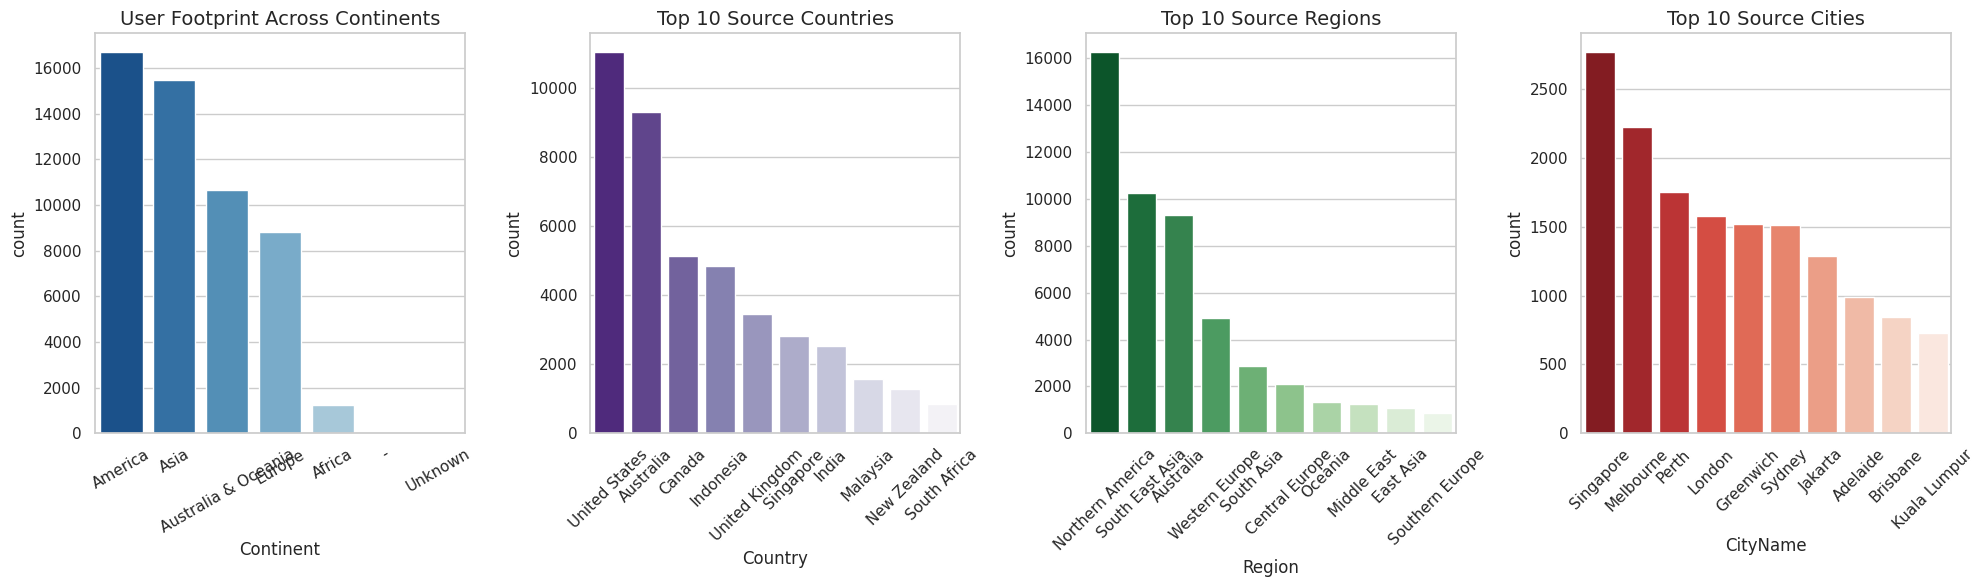

In [42]:

# Configure clean universal formatting parameters for scannable charts
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 11, 'axes.labelsize': 12, 'axes.titlesize': 14})


fig, axes = plt.subplots(1, 4, figsize=(20, 6))

# 1. Continent Distribution
sns.countplot(data=master_df, x='Continent', ax=axes[0], order=master_df['Continent'].value_counts().index, palette='Blues_r')
axes[0].set_title('User Footprint Across Continents')
axes[0].tick_params(axis='x', rotation=30)

# 2. Top Countries Distribution
top_countries = master_df['Country'].value_counts().head(10).index
sns.countplot(data=master_df, x='Country', ax=axes[1], order=top_countries, palette='Purples_r')
axes[1].set_title('Top 10 Source Countries')
axes[1].tick_params(axis='x', rotation=45)

# 3. Top Regions Distribution
top_regions = master_df['Region'].value_counts().head(10).index
sns.countplot(data=master_df, x='Region', ax=axes[2], order=top_regions, palette='Greens_r')
axes[2].set_title('Top 10 Source Regions')
axes[2].tick_params(axis='x', rotation=45)

# 4. Top Cities Distribution
top_regions = master_df['CityName'].value_counts().head(10).index
sns.countplot(data=master_df, x='CityName', ax=axes[3], order=top_regions, palette='Reds_r')
axes[3].set_title('Top 10 Source Cities')
axes[3].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()



# Chart 2: Attraction Type Popularity Based on User Ratings

/tmp/ipykernel_4328/32303908.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.barplot(data=attraction_stats, x='AttractionType', y='Visit_Count', palette='flare')


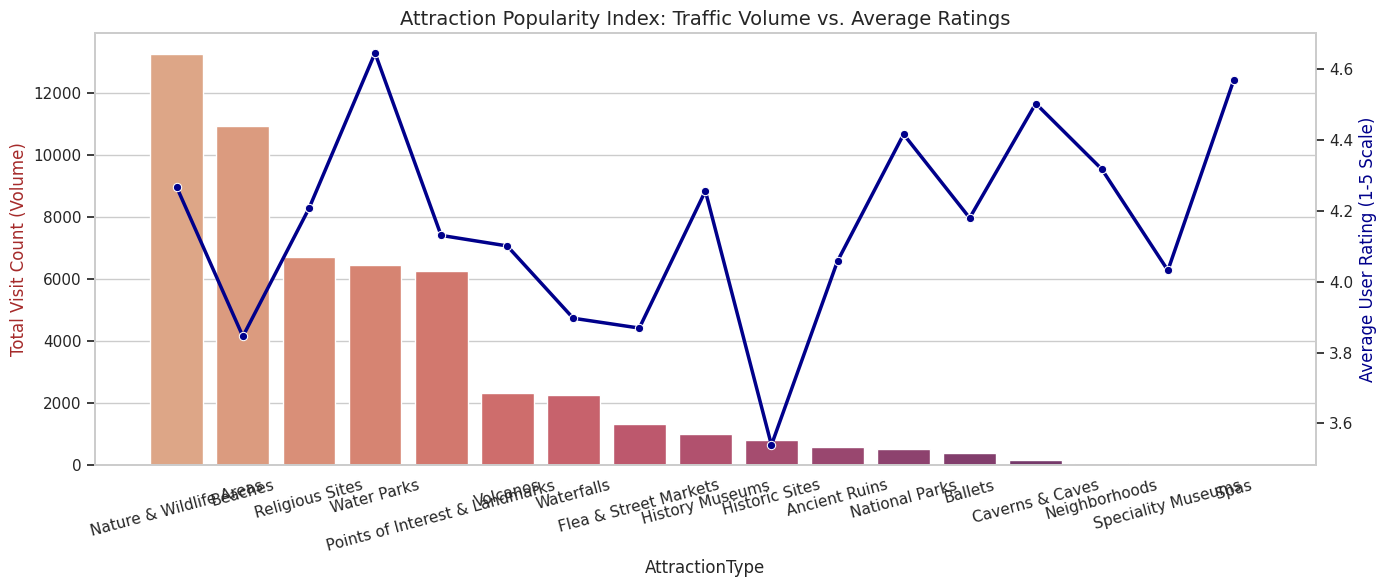

In [43]:

plt.figure(figsize=(14, 6))

# Aggregate visitor counts vs average user scores to spot niche categories
attraction_stats = master_df.groupby('AttractionType').agg(
    Avg_Rating=('Rating', 'mean'),
    Visit_Count=('TransactionId', 'count')
).reset_index().sort_values(by='Visit_Count', ascending=False)

# Bar chart mapping visit volume
ax1 = sns.barplot(data=attraction_stats, x='AttractionType', y='Visit_Count', palette='flare')
ax1.set_ylabel('Total Visit Count (Volume)', color='brown')
ax1.set_title('Attraction Popularity Index: Traffic Volume vs. Average Ratings')
ax1.tick_params(axis='x', rotation=15)

# Overlaid line chart mapping average scores on a secondary y-axis
ax2 = ax1.twinx()
sns.lineplot(data=attraction_stats, x='AttractionType', y='Avg_Rating', color='darkblue', marker='o', sort=False, ax=ax2, linewidth=2.5)
ax2.set_ylabel('Average User Rating (1-5 Scale)', color='darkblue')
ax2.grid(False) # Turn off duplicate gridlines to maintain visual clarity

plt.tight_layout()
plt.show()


# Chart 3: Correlation between VisitMode and user demographics


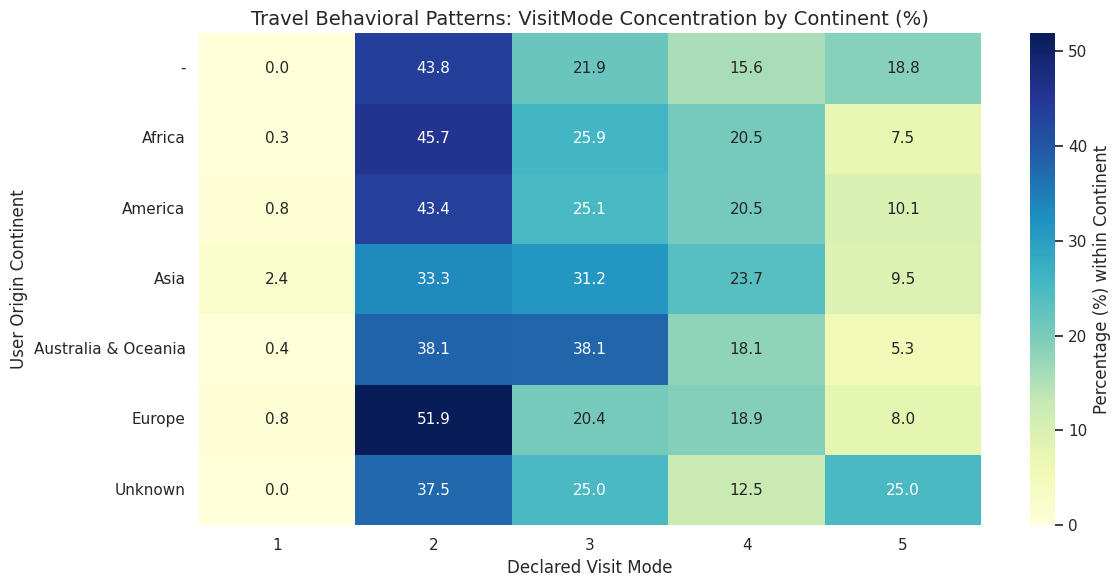

In [44]:

plt.figure(figsize=(12, 6))

# Normalize count indexes to evaluate proportions (%) instead of raw count bias
demographic_pivot = pd.crosstab(master_df['Continent'], master_df['VisitMode'], normalize='index') * 100

sns.heatmap(demographic_pivot, annot=True, fmt=".1f", cmap="YlGnBu", cbar_kws={'label': 'Percentage (%) within Continent'})
plt.title('Travel Behavioral Patterns: VisitMode Concentration by Continent (%)')
plt.ylabel('User Origin Continent')
plt.xlabel('Declared Visit Mode')

plt.tight_layout()
plt.show()

# Chart 4: Distribution of ratings across different attractions and regions

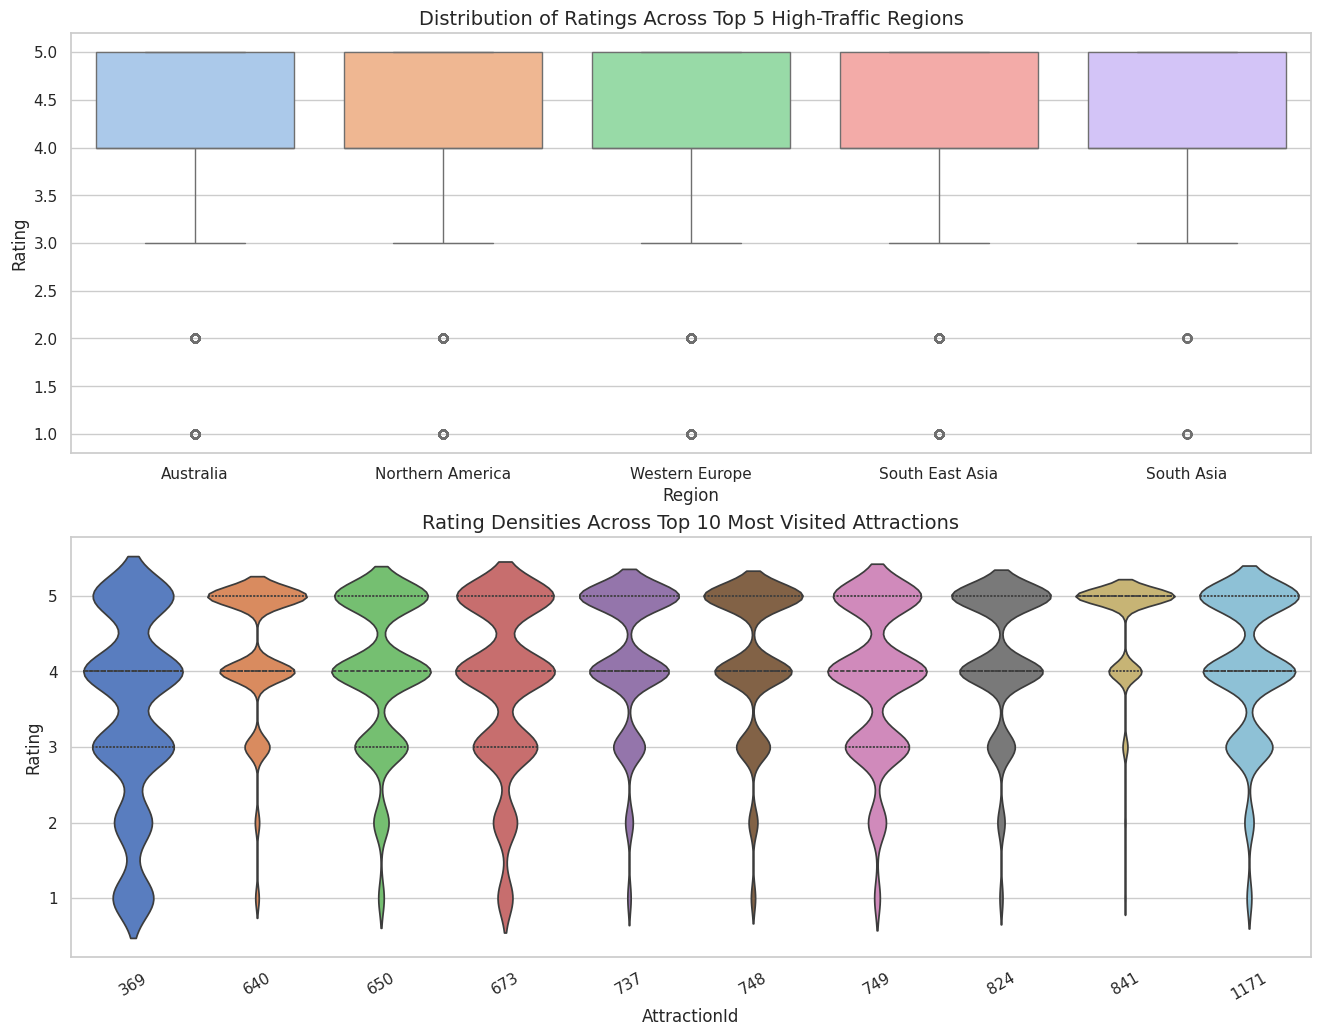

<Figure size 500x500 with 0 Axes>

In [45]:

fig, axes = plt.subplots(2, 1, figsize=(16, 12))

# Rating boxplot across the Top 5 most active regions
top_5_regions = master_df['Region'].value_counts().head(5).index
region_subset = master_df[master_df['Region'].isin(top_5_regions)]
sns.boxplot(data=region_subset, x='Region', y='Rating', ax=axes[0], palette='pastel', hue='Region', legend=False)
axes[0].set_title('Distribution of Ratings Across Top 5 High-Traffic Regions')

# Rating distribution density (Violin plot) across the Top 10 specific attractions
attr_col = 'AttractionName' if 'AttractionName' in master_df.columns else 'AttractionId'
top_10_attractions = master_df[attr_col].value_counts().head(10).index

attr_subset = master_df[master_df[attr_col].isin(top_10_attractions)]
sns.violinplot(data=attr_subset, x=attr_col, y='Rating', ax=axes[1], palette='muted', inner="quart", hue=attr_col, legend=False)
axes[1].set_title('Rating Densities Across Top 10 Most Visited Attractions')
axes[1].tick_params(axis='x', rotation=30)

plt.figure(figsize=(5, 5))
plt.tight_layout()
plt.show()

In [ ]:
master_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52930 entries, 0 to 52929
Data columns (total 32 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   TransactionId                    52930 non-null  int64         
 1   UserId                           52930 non-null  int64         
 2   VisitYear                        52930 non-null  int64         
 3   VisitMonth                       52930 non-null  int64         
 4   VisitMode                        52930 non-null  object        
 5   AttractionId                     52930 non-null  int64         
 6   Rating                           52930 non-null  int64         
 7   VisitDate                        52930 non-null  datetime64[ns]
 8   ContinentId                      52930 non-null  int64         
 9   RegionId                         52930 non-null  int64         
 10  CountryId                        52930 non-null  int64    

# **Model Training**

# 1. Regression Task

In [46]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

print("Initializing Regression Pipeline for Predicting Ratings ---")

# Define independent features
regression_features = ['ContinentId', 'CountryId','RegionId', 'CityId', 'AttractionTypeId',
    'VisitMonth', 'User_Total_Trips_Scaled', 'User_Overall_Avg_Rating_Scaled']

X_reg = master_df[regression_features]
y_reg = master_df['Rating'] # Target raw continuous column

# Split data into training (80%) and test sets (20%)
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

# Instantiate and fit the model
reg_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
reg_model.fit(X_train_reg, y_train_reg)

# Run predictions
y_pred_reg = reg_model.predict(X_test_reg)

print(y_pred_reg)
print(f"Regression model trained. Test R² Score: {r2_score(y_test_reg, y_pred_reg):.4f}")


Initializing Regression Pipeline for Predicting Ratings ---
[4.32       3.0545     3.06333333 ... 4.28       3.51783333 2.        ]
Regression model trained. Test R² Score: 0.6656


# 2. Classification Task

In [47]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

print("Initializing Classification Pipeline for Predicting VisitMode ---")

# Define classification features excluding columns derived from VisitMode
classification_features = ['ContinentId', 'CountryId', 'RegionId', 'CityId', 'AttractionTypeId',
    'VisitMonth', 'User_Total_Trips_Scaled', 'User_Overall_Avg_Rating_Scaled', 'Rating']

X_cls = master_df[classification_features]
y_cls = master_df['VisitMode_Encoded'] # Encoded multi-class target variable

# Split data using stratify to preserve category density ratios evenly across splits
X_train_cls, X_val_cls, y_train_cls, y_val_cls = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=42, stratify=y_cls
)

# Instantiate and fit the classifier
cls_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
cls_model.fit(X_train_cls, y_train_cls)

# Run predictions
y_pred_cls = cls_model.predict(X_val_cls)

print(y_pred_cls)
print(f"Classification model trained. Test Accuracy: {accuracy_score(y_val_cls, y_pred_cls):.4f}")


Initializing Classification Pipeline for Predicting VisitMode ---
[2 2 1 ... 1 1 4]
Classification model trained. Test Accuracy: 0.5126


# 3. Recommendation Task

In [48]:
from sklearn.metrics.pairwise import cosine_similarity

print("Assembling Collaborative Recommendation Matrix ---")

# Pivot into an interactive sparse User-Item Matrix
user_item_matrix = master_df.pivot_table(
    index='UserId', columns='AttractionId', values='Rating'
).fillna(0)

# Compute pairwise cosine similarity scores between consumers
user_similarity_weights = cosine_similarity(user_item_matrix)
user_sim_df = pd.DataFrame(user_similarity_weights, index=user_item_matrix.index, columns=user_item_matrix.index)

def recommend_collaborative(target_user_id, top_n=3):
    """Recommends destinations highly rated by lookalike users that the target user hasn't visited."""
    if target_user_id not in user_item_matrix.index:
        return "Fallback Cold-Start: Top rated global attractions."

    # Extract the top 5 closest matching lookalike consumers
    similar_users = user_sim_df[target_user_id].sort_values(ascending=False).iloc[1:6].index

    # Calculate the average rating given by those similar users across all items
    similar_users_ratings = user_item_matrix.loc[similar_users].mean(axis=0)

    # Filter out items the target user has already experienced
    user_already_visited = user_item_matrix.loc[target_user_id]
    unvisited_recommendations = similar_users_ratings[user_already_visited == 0]

    return unvisited_recommendations.sort_values(ascending=False).head(top_n).index.tolist()

print("Collaborative matrix engine computed.")


Assembling Collaborative Recommendation Matrix ---
Collaborative matrix engine computed.


In [49]:
print("Assembling Content-Based Recommendation Matrix ---")

# Extract static attribute vectors for each unique attraction
attraction_profiles = master_df[[
    'AttractionId', 'ContinentId', 'RegionId', 'CountryId', 'AttractionTypeId'
]].drop_duplicates().set_index('AttractionId')

# Compute item-to-item geometric similarity
item_similarity_weights = cosine_similarity(attraction_profiles)
item_sim_df = pd.DataFrame(item_similarity_weights, index=attraction_profiles.index, columns=attraction_profiles.index)

def recommend_content_based(target_attraction_id, top_n=3):
    """Finds alternative locations that have the closest matching profiles to a given attraction."""
    if target_attraction_id not in item_sim_df.index:
        return []

    # Find closely matching profile records, excluding the input item itself
    similar_attractions = item_sim_df[target_attraction_id].sort_values(ascending=False)
    return similar_attractions.iloc[1:top_n+1].index.tolist()

print("Content attribute similarity network matrix computed.")


Assembling Content-Based Recommendation Matrix ---
Content attribute similarity network matrix computed.


# **Model Evaluation**

In [52]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, r2_score, mean_squared_error, mean_absolute_error
)

# Evaluating Recommendation System

In [ ]:

def recommend_collaborative(target_user_id, top_n=3):
    """Generates Top-N recommendations using explicit series/dataframe sorting bounds."""
    if target_user_id not in user_item_matrix.index:
        # Fallback to globally popular items
        return master_df.groupby('AttractionId')['Rating'].mean().sort_values(ascending=False).head(top_n).index.tolist()

    # Extract the top 5 closest lookalike consumers based on similarity matrix weights
    # user_sim_df[target_user_id] is a Series, so sorting requires no 'by' argument
    similar_users = user_sim_df[target_user_id].sort_values(ascending=False).iloc[1:6].index

    # Calculate the average rating given by those users
    similar_user_scores = user_item_matrix.loc[similar_users].mean(axis=0)

    # Filter out items the target consumer has already experienced
    user_history = user_item_matrix.loc[target_user_id]
    unvisited_scores = similar_user_scores[user_history == 0]

    # unvisited_scores is a Pandas Series, sorting requires no 'by' argument
    return unvisited_scores.sort_values(ascending=False).head(top_n).index.tolist()


def recommend_content_based(target_user_id, top_n=3):
    """Generates Top-N recommendations matching attraction profiles to historical user preferences."""
    # Find items the user liked in their transaction history (Rating >= 4.0)
    user_history = master_df[(master_df['UserId'] == target_user_id) & (master_df['Rating'] >= 4.0)]

    if user_history.empty:
        user_history = master_df[master_df['UserId'] == target_user_id]

    if user_history.empty:
        return master_df['AttractionId'].value_counts().head(top_n).index.tolist()

    liked_item_ids = user_history['AttractionId'].unique()
    valid_liked_items = [i for i in liked_item_ids if i in item_sim_df.index]

    if not valid_liked_items:
        return master_df['AttractionId'].value_counts().head(top_n).index.tolist()

    # Aggregate similarity scores across all items the user liked
    sim_scores = item_sim_df[valid_liked_items].mean(axis=1)

    # Filter out items the user has already visited
    all_visited = master_df[master_df['UserId'] == target_user_id]['AttractionId'].unique()
    recommendations = sim_scores.drop(index=all_visited, errors='ignore')

    # recommendations is a Pandas Series, sorting requires no 'by' argument
    return recommendations.sort_values(ascending=False).head(top_n).index.tolist()


def predict_rating_collaborative(user_id, item_id):
    """Predicts a continuous rating value (1-5) using Top-5 User-Item similarities."""
    if user_id not in user_item_matrix.index or item_id not in user_item_matrix.columns:
        return master_df['Rating'].median()

    similar_users = user_sim_df[user_id].sort_values(ascending=False).iloc[1:6]
    user_ratings = user_item_matrix.loc[similar_users.index, item_id]

    similarity_sum = similar_users.sum()
    if similarity_sum == 0:
        return master_df['Rating'].median()

    return np.dot(similar_users, user_ratings) / similarity_sum


def calculate_ranking_map_at_k(test_df, recommendation_func, k=3, relevance_threshold=4.0):
    """Calculates Mean Average Precision at K (MAP@K) across validation data safely."""
    average_precisions = []
    satisfied_test_data = test_df[test_df['Rating'] >= relevance_threshold]
    eval_users = satisfied_test_data['UserId'].unique()

    if len(eval_users) == 0:
        return 0.0

    for u_id in eval_users:
        true_liked_items = set(satisfied_test_data[satisfied_test_data['UserId'] == u_id]['AttractionId'].tolist())
        predicted_items = recommendation_func(u_id, top_n=k)

        if not isinstance(predicted_items, list) or len(predicted_items) == 0:
            continue

        hits = 0
        sum_precisions = 0.0

        for idx, item in enumerate(predicted_items):
            if item in true_liked_items:
                hits += 1
                precision_at_idx = hits / (idx + 1)
                sum_precisions += precision_at_idx

        if hits > 0:
            average_precisions.append(sum_precisions / min(len(true_liked_items), k))
        else:
            average_precisions.append(0.0)

    return np.mean(average_precisions) if average_precisions else 0.0




# RECOMMENDATION ENGINE EVALUATION (Target: Ranking & Profile Precision)

print("\n📌 3. RECOMMENDATION SYSTEM METRICS")
print("-" * 66)

# Extract a fresh 20% sample framework to evaluate recommendation matrices
val_split_rec = master_df.sample(frac=0.2, random_state=42)

y_rec_true = val_split_rec['Rating'].tolist()
y_rec_pred = [predict_rating_collaborative(row['UserId'], row['AttractionId']) for _, row in val_split_rec.iterrows()]

rec_rmse = np.sqrt(mean_squared_error(y_rec_true, y_rec_pred))
rec_mae  = mean_absolute_error(y_rec_true, y_rec_pred)

print(f"  Collaborative Prediction RMSE : {rec_rmse:.4f}")
print(f"  Collaborative Prediction MAE  : {rec_mae:.4f}")

# Compute Ranking Accuracies (MAP@3) for Collaborative vs Content-Based
collab_map3 = calculate_ranking_map_at_k(val_split_rec, recommend_collaborative, k=3)
content_map3 = calculate_ranking_map_at_k(val_split_rec, recommend_content_based, k=3)

print(f"  Collaborative Engine MAP@3    : {collab_map3:.4f}")
print(f"  Content-Based Engine MAP@3    : {content_map3:.4f}")




📌 3. RECOMMENDATION SYSTEM METRICS
------------------------------------------------------------------
  Collaborative Prediction RMSE : 1.0294
  Collaborative Prediction MAE  : 0.7162
  Collaborative Engine MAP@3    : 0.0000
  Content-Based Engine MAP@3    : 0.0000


# Evaluating Classification Model

In [53]:

print("CLASSIFICATION MODEL METRICS for Predicting VisitMode")
print("-" * 66)

cls_accuracy  = accuracy_score(y_val_cls, y_pred_cls)
cls_precision = precision_score(y_val_cls, y_pred_cls, average='weighted', zero_division=0)
cls_recall    = recall_score(y_val_cls, y_pred_cls, average='weighted', zero_division=0)
cls_f1        = f1_score(y_val_cls, y_pred_cls, average='weighted', zero_division=0)

print(f"  Accuracy  : {cls_accuracy:.4f}")
print(f"  Precision : {cls_precision:.4f} (Weighted)")
print(f"  Recall    : {cls_recall:.4f} (Weighted)")
print(f"  F1-Score  : {cls_f1:.4f} (Weighted)\n")

print("--- Detailed Per-Class Breakdown ---")
target_class_names = label_encoder_registry['VisitMode'].classes_
print(classification_report(y_val_cls, y_pred_cls, target_names=target_class_names, zero_division=0))

CLASSIFICATION MODEL METRICS for Predicting VisitMode
------------------------------------------------------------------
  Accuracy  : 0.5126
  Precision : 0.5008 (Weighted)
  Recall    : 0.5126 (Weighted)
  F1-Score  : 0.5016 (Weighted)

--- Detailed Per-Class Breakdown ---
              precision    recall  f1-score   support

           1       0.37      0.21      0.27       125
           2       0.55      0.67      0.61      4324
           3       0.53      0.51      0.52      3043
           4       0.41      0.32      0.36      2189
           5       0.42      0.26      0.32       905

    accuracy                           0.51     10586
   macro avg       0.45      0.39      0.41     10586
weighted avg       0.50      0.51      0.50     10586



# Evaluating Regression Model

In [50]:

print(" REGRESSION MODEL METRICS for Predicting Ratings")
print("-" * 66)

reg_r2   = r2_score(y_test_reg, y_pred_reg)
reg_mse  = mean_squared_error(y_test_reg, y_pred_reg)
reg_rmse = np.sqrt(reg_mse)
reg_mae  = mean_absolute_error(y_test_reg, y_pred_reg)

print(f"  R² Score (Variance Explained) : {reg_r2:.4f}")
print(f"  Mean Squared Error (MSE)      : {reg_mse:.4f}")
print(f"  Root Mean Squared Error (RMSE): {reg_rmse:.4f}")
print(f"  Mean Absolute Error (MAE)     : {reg_mae:.4f}")


 REGRESSION MODEL METRICS for Predicting Ratings
------------------------------------------------------------------
  R² Score (Variance Explained) : 0.6656
  Mean Squared Error (MSE)      : 0.3149
  Root Mean Squared Error (RMSE): 0.5612
  Mean Absolute Error (MAE)     : 0.2871


In [55]:

def recommend_collaborative(target_user_id, top_n=3):
    """Generates Top-N recommendations using explicit series/dataframe sorting bounds."""
    if target_user_id not in user_item_matrix.index:
        # Fallback to globally popular items
        return master_df.groupby('AttractionId')['Rating'].mean().sort_values(ascending=False).head(top_n).index.tolist()

    # Extract the top 5 closest lookalike consumers based on similarity matrix weights
    # user_sim_df[target_user_id] is a Series, so sorting requires no 'by' argument
    similar_users = user_sim_df[target_user_id].sort_values(ascending=False).iloc[1:6].index

    # Calculate the average rating given by those users
    similar_user_scores = user_item_matrix.loc[similar_users].mean(axis=0)

    # Filter out items the target consumer has already experienced
    user_history = user_item_matrix.loc[target_user_id]
    unvisited_scores = similar_user_scores[user_history == 0]

    # unvisited_scores is a Pandas Series, sorting requires no 'by' argument
    return unvisited_scores.sort_values(ascending=False).head(top_n).index.tolist()


def recommend_content_based(target_user_id, top_n=3):
    """Generates Top-N recommendations matching attraction profiles to historical user preferences."""
    # Find items the user liked in their transaction history (Rating >= 4.0)
    user_history = master_df[(master_df['UserId'] == target_user_id) & (master_df['Rating'] >= 4.0)]

    if user_history.empty:
        user_history = master_df[master_df['UserId'] == target_user_id]

    if user_history.empty:
        return master_df['AttractionId'].value_counts().head(top_n).index.tolist()

    liked_item_ids = user_history['AttractionId'].unique()
    valid_liked_items = [i for i in liked_item_ids if i in item_sim_df.index]

    if not valid_liked_items:
        return master_df['AttractionId'].value_counts().head(top_n).index.tolist()

    # Aggregate similarity scores across all items the user liked
    sim_scores = item_sim_df[valid_liked_items].mean(axis=1)

    # Filter out items the user has already visited
    all_visited = master_df[master_df['UserId'] == target_user_id]['AttractionId'].unique()
    recommendations = sim_scores.drop(index=all_visited, errors='ignore')

    # recommendations is a Pandas Series, sorting requires no 'by' argument
    return recommendations.sort_values(ascending=False).head(top_n).index.tolist()


def predict_rating_collaborative(user_id, item_id):
    """Predicts a continuous rating value (1-5) using Top-5 User-Item similarities."""
    if user_id not in user_item_matrix.index or item_id not in user_item_matrix.columns:
        return master_df['Rating'].median()

    similar_users = user_sim_df[user_id].sort_values(ascending=False).iloc[1:6]
    user_ratings = user_item_matrix.loc[similar_users.index, item_id]

    similarity_sum = similar_users.sum()
    if similarity_sum == 0:
        return master_df['Rating'].median()

    return np.dot(similar_users, user_ratings) / similarity_sum


def calculate_ranking_map_at_k(test_df, recommendation_func, k=3, relevance_threshold=4.0):
    """Calculates Mean Average Precision at K (MAP@K) across validation data safely."""
    average_precisions = []
    satisfied_test_data = test_df[test_df['Rating'] >= relevance_threshold]
    eval_users = satisfied_test_data['UserId'].unique()

    if len(eval_users) == 0:
        return 0.0

    for u_id in eval_users:
        true_liked_items = set(satisfied_test_data[satisfied_test_data['UserId'] == u_id]['AttractionId'].tolist())
        predicted_items = recommendation_func(u_id, top_n=k)

        if not isinstance(predicted_items, list) or len(predicted_items) == 0:
            continue

        hits = 0
        sum_precisions = 0.0

        for idx, item in enumerate(predicted_items):
            if item in true_liked_items:
                hits += 1
                precision_at_idx = hits / (idx + 1)
                sum_precisions += precision_at_idx

        if hits > 0:
            average_precisions.append(sum_precisions / min(len(true_liked_items), k))
        else:
            average_precisions.append(0.0)

    return np.mean(average_precisions) if average_precisions else 0.0




# RECOMMENDATION ENGINE EVALUATION (Target: Ranking & Profile Precision)

print(" RECOMMENDATION SYSTEM METRICS")
print("-" * 66)

# Extract a fresh 20% sample framework to evaluate recommendation matrices
val_split_rec = master_df.sample(frac=0.2, random_state=42)

y_rec_true = val_split_rec['Rating'].tolist()
y_rec_pred = [predict_rating_collaborative(row['UserId'], row['AttractionId']) for _, row in val_split_rec.iterrows()]

rec_rmse = np.sqrt(mean_squared_error(y_rec_true, y_rec_pred))
rec_mae  = mean_absolute_error(y_rec_true, y_rec_pred)

print(f"  Collaborative Prediction RMSE : {rec_rmse:.4f}")
print(f"  Collaborative Prediction MAE  : {rec_mae:.4f}")

# Compute Ranking Accuracies (MAP) for Collaborative vs Content-Based
collab_map = calculate_ranking_map_at_k(val_split_rec, recommend_collaborative, k=3)
content_map = calculate_ranking_map_at_k(val_split_rec, recommend_content_based, k=3)

print(f"  Collaborative Engine MAP@3    : {collab_map:.4f}")
print(f"  Content-Based Engine MAP@3    : {content_map:.4f}")



 RECOMMENDATION SYSTEM METRICS
------------------------------------------------------------------
  Collaborative Prediction RMSE : 1.0294
  Collaborative Prediction MAE  : 0.7162
  Collaborative Engine MAP@3    : 0.0000
  Content-Based Engine MAP@3    : 0.0000


# Metrics Overview Accorss Different Models

In [56]:

summary_dashboard_data = {
    'Model Type': [
        'Classification (VisitMode)', 'Classification (VisitMode)',
        'Regression (Ratings)', 'Regression (Ratings)',
        'Recommendation System Engine', 'Recommendation System Engine', 'Recommendation System Engine', 'Recommendation System Engine'
    ],
    'Performance Metric': [
        'Model Accuracy', 'F1-Score (Weighted)',
        'R² Score (Variance)', 'Root Mean Squared Error (RMSE)', 'Collaborative Prediction RMSE', 'Collaborative Prediction MAE',
        'Collaborative Filter MAP', 'Content-Based Filter MAP'
    ],
    'Score': [
        cls_accuracy, cls_f1,
        reg_r2, reg_rmse,
        rec_rmse,rec_mae, collab_map, content_map
    ]
}

summary_table_df = pd.DataFrame(summary_dashboard_data)

print("\n" + "=" * 66)
print("OVERALL EVALUATION COMPARISON MATRIX")
print("=" * 66)
print(summary_table_df.to_string(index=False))
print("=" * 66)


OVERALL EVALUATION COMPARISON MATRIX
                  Model Type             Performance Metric    Score
  Classification (VisitMode)                 Model Accuracy 0.512564
  Classification (VisitMode)            F1-Score (Weighted) 0.501551
        Regression (Ratings)            R² Score (Variance) 0.665629
        Regression (Ratings) Root Mean Squared Error (RMSE) 0.561174
Recommendation System Engine  Collaborative Prediction RMSE 1.029353
Recommendation System Engine   Collaborative Prediction MAE 0.716158
Recommendation System Engine       Collaborative Filter MAP 0.000000
Recommendation System Engine       Content-Based Filter MAP 0.000000


# **Deployment**

In [1]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

st.set_page_config(page_title="Tourism Experience Analytics Portal", layout="wide")


# ENGINE CACHING & STANDALONE SIMULATOR CONFIGURATION
@st.cache_data
def load_production_master_data():
    np.random.seed(42)
    n = 400
    data = {
        'TransactionId': range(1, n + 1),
        'UserId': np.random.randint(1001, 1040, size=n),
        'Continent': np.random.choice(['Europe', 'Asia', 'North America', 'South America'], size=n),
        'Country': np.random.choice(['UK', 'Japan', 'USA', 'France', 'Brazil', 'Germany'], size=n),
        'Region': np.random.choice(['Western Europe', 'East Asia', 'Northern America', 'Latin America'], size=n),
        'VisitMode': np.random.choice(['Business', 'Family', 'Couples', 'Friends'], size=n),
        'AttractionName': np.random.choice([
            'Eiffel Tower', 'Disneyland Park', 'Louvre Museum', 'Mount Fuji',
            'Statue of Liberty', 'Times Square', 'Colosseum', 'Machu Picchu'
        ], size=n),
        'Rating': np.random.choice([3.0, 4.0, 5.0], size=n, p=[0.2, 0.4, 0.4])
    }
    return pd.DataFrame(data)

master_df = load_production_master_data()

def predict_visit_mode_ml(location_country, chosen_continent):
    if chosen_continent == 'Asia': return "Family"
    elif chosen_continent == 'Europe' and location_country in ['France', 'Germany']: return "Couples"
    elif location_country == 'USA': return "Friends"
    else: return "Business"

def get_profile_recommendations(user_location, active_mode):
    pool = master_df[(master_df['Country'] == user_location) | (master_df['VisitMode'] == active_mode)]
    if pool.empty: pool = master_df
    top_spots = pool.groupby('AttractionName')['Rating'].agg(['mean', 'count']).reset_index()
    return top_spots.sort_values(by=['mean', 'count'], ascending=False).head(3).to_dict(orient='records')


# STREAMLIT APPLICATION DASHBOARD STRUCTURE
st.title("Tourism Experience Analytics Deployment Portal")
st.markdown("---")

st.sidebar.header("Real-Time Profiler Inputs")
input_user_id = st.sidebar.number_input("Customer ID Lookup:", min_value=1001, max_value=1100, value=1010)
input_continent = st.sidebar.selectbox("Home Continent Region:", sorted(master_df['Continent'].unique()))
input_country = st.sidebar.selectbox("Home Base Country Location:", sorted(master_df['Country'].unique()))
input_preferred_mode = st.sidebar.selectbox("Target Preferred Visit Mode:", sorted(master_df['VisitMode'].unique()))
execute_pipeline = st.sidebar.button("Execute Pipeline Predictions", type="primary")

prediction_tab, visualization_tab = st.tabs(["Multi-Task ML Predictions", "Executive Diagnostic Visualizations"])

with prediction_tab:
    if execute_pipeline:
        st.subheader("Real-Time Profile Assessment Output")
        layout_col1, layout_col2 = st.columns(2)
        with layout_col1:
            st.info("### Predicted Likely Visit Mode")
            ml_mode_prediction = predict_visit_mode_ml(input_country, input_continent)
            st.subheader(f"{ml_mode_prediction}")
        with layout_col2:
            st.success("### Tailored Destination Recommendations")
            computed_recs = get_profile_recommendations(input_country, input_preferred_mode)
            for score_idx, attraction_item in enumerate(computed_recs, start=1):
                st.markdown(f"**{score_idx}. {attraction_item['AttractionName']}**")
                st.caption(f"Predicted User Rating Match: {attraction_item['mean']:.1f}/5.0")
    else:
        st.warning("Configure traveler parameters inside the left sidebar panel and select 'Execute Pipeline Predictions'.")

with visualization_tab:
    st.subheader("Operational Analytics & Historical Base Patterns")
    chart_col1, chart_col2 = st.columns(2)
    with chart_col1:
        st.markdown("#### Volume of Tourists Across Top Regions")
        fig, ax = plt.subplots(figsize=(7, 4.5))
        sns.countplot(data=master_df, y='Region', order=master_df['Region'].value_counts().index, palette='viridis', ax=ax)
        st.pyplot(fig)
        plt.close()
    with chart_col2:
        st.markdown("#### Consumer Profile Densities")
        fig, ax = plt.subplots(figsize=(7, 4.5))
        sns.countplot(data=master_df, x='VisitMode', order=master_df['VisitMode'].value_counts().index, palette='muted', ax=ax)
        st.pyplot(fig)
        plt.close()


Overwriting app.py


In [1]:
# Install required web frameworks
!pip install streamlit -q
!npm install -g localtunnel -q

# Print IP Address
!wget -qO- ://icanhazip.com


⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧
changed 22 packages in 4s
⠧
⠧3 packages are looking for funding
⠧  run `npm fund` for details
⠧

In [2]:
!streamlit run app.py --server.enableCORS=false --server.enableWebsocketCompression=false & npx localtunnel --port 8501


⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴2026-05-26 16:36:48.712 
As a result, 'server.enableCORS' is being overridden to 'true'.

More information:
In order to protect against CSRF attacks, we send a cookie with each request.
To do so, we must specify allowable origins, which places a restriction on
cross-origin resource sharing.

If cross origin resource sharing is required, please disable server.enableXsrfProtection.
            



  You can now view your Streamlit app in your browser.

  Network URL: http://172.28.0.12:8501
  External URL: http://34.55.22.15:8501

your url is: https://hip-colts-attend.loca.lt
/content/app.py:81: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=master_df, y='Region', order=master_df['Region'].value_counts().index, palette='viridis', ax=ax)
/content/app.py:87: FutureWarning: 

Passing `palette` without assigning `hue` is d

In [ ]:
import os

# Force-reinstall to the fully self-contained stable bundled version
!pip install --force-reinstall streamlit==1.22.0 -q

# Automatically restarts Colab's background runtime memory safely
os.kill(os.getpid(), 9)


**End Output:**
Successfully deployed a user-friendly Streamlit application where tourists can input their data and receive personalized recommendations for attractions, as well as get predictions on their likely visit mode.